In [21]:
# 01. 공통 코드
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
from codecs import xmlcharrefreplace_errors

warnings.filterwarnings("ignore")

# 라이브러리 임폴트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
from matplotlib import rc


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    rc('font', family='Malgun Gothic')
else:
    rc('font', family='Malgun Gothic')

# 데이터프레임 출력용 함수
from IPython.display import Image

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:,.4f}'.format

# 데이터 프레임 모든 필드 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 난수 시드
random_seed = 123

In [22]:
# 1. 알고리즘 선택하기
# 실무에서 많이 사용되는 처리 패턴인 분류를 대상으로, 대표적인 알고리즘을 알아보고 선택하는 방법도 알아봄
# 알고리즘을 선택하는 원칙을 알아보고 각 알고리즘이 어떤 데이터 전처리를 필요로 하는지 알아봄.

# 01. 대표적인 분류 알고리즘과 특징
# * 구현 방식에 따른 분류
# 1) 손실 함수 타입
# 로지스틱 회귀 : 시그모이드 함수의 출력을 확률로 취급, 결정 경계는 직선 형태
# 서포트 벡터 머신(커널) : 커널 트릭을 적용해 직선 이외의 결정 경계를 가질 수 있음
# 신경망 : 중간층을 추가하는 방법으로 직선 이외의 결정 경계를 가질 수 있음

# 2) 결정 트리 타입
# 결정 트리 : 특정 필드의 값을 기준으로 그룹을 나누는 과정을 반복
# 랜덤 포레스트 : 학습 데이터의 일부분으로 여러 개의 결정 트리를 만든 다음, 결정 트리 간의 다수결로 결정
# XGBoost : 오분류했던 데이터로 분류 모델을 만들어 정확도를 향상시키는 기법

# 구현 방식은 손실 함수 타입과 결정 트리 방식의 두 가지가 있음
# 전처리 기법 중 데이터 정규화는 손실 함수 타입에서 효과적인 기법이며, 결정 트리 타입에서는 효과를 보기 어려움
# 알고리즘 선택에 따라 필요한 전처리 기법도 달라지기 때문에 모델 내부에 대한 이해없이
# 그냥 활용만 할 생각이더라도 알고리즘의 구현 방식이 무엇인지는 알아둘 필요가 있음

# 1) 손실 함수 타입
# 모델의 구조가 수학적 함수로 결정되 있고, 학습은 함수의 파라미터를 최적화하는 과정에 해당
# 예를 들어 로지스틱 회귀는 1차 함수를 사용해 세 개의 파라미터를 최적화

# 파라미터를 최적화하는 구체적인 방법은 모델의 정확도가 높아질수록 함수값이 작아지는 (모두 정답을 맞히면 0이 되는) 함수인
# '손실 함수'를 정의하고 수학적인 방법을 통해 이 함수의 함수값이 최소가 되는 파라미터 구성


# 2) 결정 트리 타입
# 특정 필드에 역치 threshold를 설정하고 필드 값이 이 역치보다 큰가 작은가를 기준으로 그룹을 나누는 방식
# 어떤 필드의 값이 어떤 역치 값에 따라 어떻게 그룹이 나뉘는가에 대한 규칙을 결정하는 것이 학습 과정이 됨
# 랜덤 포레스트의 XGBoost는 결정 트리를 개량한 알고리즘으로
# 여러 개의 결정 트리를 조합하는 방식으로 모델의 정확도를 향상시킨 모델

# 손실 함수 타입은 입력값이 극단적으로 커지거나 작아지는 경우 알고리즘이 제대로 작동하지 않음
# 이 경우에는 데이터 정규화를 미리 거치는 편이 좋음
# 결정 트리 타입은 단순히 값의 대소 비교만으로 분류가 이루어지기 때문에 정규화처럼 값의 배율을 조정하는 방법은 영향을 미치지 못함


# 02. 사용할 데이터
# 알고리즘을 살펴볼 때 사용한 입력 데이터를 유형별로 세 가지 준비
# 알고리즘의 이해를 위한 입력 데이터라 단순히 2차원 데이터를 사용
# (x, y)와 같은 2차원 데이터를 입력해 O, X를 예측하는 모델이 대상

In [23]:
# 1) 데이터 생성
# 라이브러리 임포트
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.datasets import make_classification

# make_moons, make_circles: 가상 데이터 받기

# 선형 데이터
x1, y1 = make_classification(n_features=2, n_redundant=0, n_clusters_per_class=1,
                             n_informative=2, n_samples=200, n_classes=2, random_state=random_seed)

# 초승달형 데이터 (선형 분리 불가능)
x2, y2 = make_moons(noise=0.005, random_state=random_seed, n_samples=200)

# 원형 데이터 (선형 분리 불가능)
x3, y3 = make_circles(noise=0.02, n_samples=200,random_state=random_seed)

# 세 가지 데이터를 Datalist 변수에 저장
DataList = [(x1, y1), (x2, y2), (x3, y3)]

# N : 데이터의 가짓수
N = len(DataList)
print(N)

3


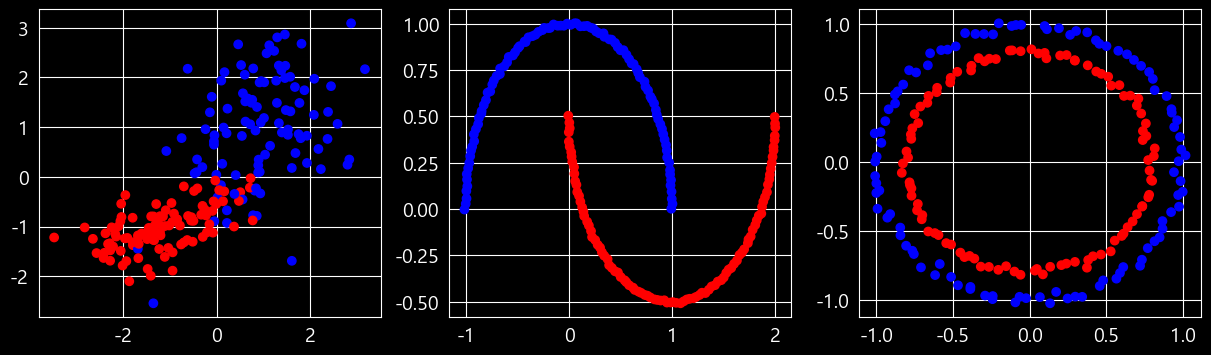

In [24]:
# 2) 데이터의 산점도 그리기
plt.rcParams['axes.unicode_minus'] = False
# 산포도 그리기
plt.figure(figsize=(15,4))

# 컬러맵 정의
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['#0000FF', 'red'])

for i, data in enumerate(DataList):
    x, y = data
    ax = plt.subplot(1, N, i + 1)
    ax.scatter(x[:,0], x[:,1], c=y, cmap=cmap)

In [25]:
# 첫 번째 데이터는 '선형 분리 가능'한 데이터로 직선을 그어 두 그룹을 나눌 수 있는 유형의 데이터
# 다만 경계 부근에 약간 데이터가 섞여 있어서 완전히 깔끔하게 분리되지는 않음
# 각 알고리즘마다 이렇게 섞인 데이터를 어느정도 다르게 처리

# 두 번째 데이터는 직선으로는 그룹을 나눌 수 없는 '선형 분리가 불가능'한 데이터

# 세 번째 데이터는 경계선이 원형이어서 역시 '선형 분리가 불가능'한 데이터

# 실제 업부에서 쓰이는 데이터는 첫 번째 데이터처럼 '선형 분리 가능'한 데이터가 많음
# 하지만 일부는 복잡한 데이터도 분명히 있기 때문에 복잡한 데이터를 처리할 수 있는지도
# 알고리즘을 선택하는 주요한 기준 중 하나

# 정리
# * 세 종류의 예제 데이터는 각각 파란색과 검은색 2차원 점 데이터로 100개로 구성
# * 결과 표시 함수는 100개의 점을 학습용과 검증용으로 50개씩 분할
# * 산점도에 학습 데이터는 X, 검증 데이터는 0으로 구분해 출력
# * 결과 표시 함수 실행 전, 알고리즘은 이미 선택된 상태이며 이 알고리즘을 함수에 인자로 전달
# * 인자로 전달받은 알고리즘을 이용해 '학습', '예측', '평가'를 모두 결과 표시 함수에서 수행
# * 평가 단계에서 학습 데이터와 검증 데이터에 대한 정확도를 따로 계산해 '검증 데이터 : 0.92 학습 데이터 : 0.91'과 같이 출력
# * 각 데이터 점은 해당하는 그룹에 따라 파란색 / 회색으로 나눠 표시
# * 모델의 확신도(confidence)를 음영의 진하기로 표시
# * 진한 부분은 확신도가 높은 부분이고 (확률이 0 또는 1에 가까움), 옅은 부분은 확신도가 낮은 부분(확신도가 0.5에 가까움)
# * 결정 경계가 있는 알고리즘은 결정 경계를 굵은 선으로 표시(일부 알고리즘은 결정 경계를 구할 수 없음)


In [26]:
from sklearn.model_selection import train_test_split

# 결정 경계를 그리는 함수

def plot_boundary(ax, x, y, algorithm):
    '''
    주어진 알고리즘을 사용하여 결정 경계를 시각화하는 함수
    ax : Matplotlib의 서브 플롯(subplot) 객체로, 결정 경계를 그릴 축
    x : 예측 변수
    y : 타겟 변수
    algorithm : 사용할 알고리즘
    '''
    # 1) 입력 데이터를 훈련용, 테스트용 데이터로 분리
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=random_seed)

    # 컬러맵 정의
    from matplotlib.colors import ListedColormap
    cmap1 = plt.cm.bwr
    cmap2 = ListedColormap(['#0000FF', 'red'])

    # 2) 훈령용 데이터로 알고리즘 모델 생성 호, 테스트 데이터를 사용하여 정확도를 평가
    h = 0.005
    algorithm.fit(x_train, y_train)
    score_test = algorithm.score(x_test, y_test) # 테스트 셋으로 정확도 평가
    score_train = algorithm.score(x_train, y_train) # 훈령용 셋으로 정확도 평가

    # 3) 입력 데이터의 범위를 기반으로 결정 경계를 생성
    f1_min = x[:,0].min()- 0.5
    f1_max = x[:,0].max()+ 0.5
    f2_min = x[:,0].min()- 0.5
    f2_max = x[:,0].max()+ 0.5
    f1, f2 = np.meshgrid(np.arange(f1_min, f1_max, h), np.arange(f2_min, f2_max, h))

    # 4) 알고리즘이 결정 함수를 가지고 있는 경우, 확신도를 구하고, 가지고 있지 않은 경우, 예측 확률로 구하고 경계를 그림
    # 확신도 데이터 구함
    if hasattr(algorithm, 'decision_function'):
        Z = algorithm.decision_function(np.c_[f1.ravel(), f2.ravel()])
        Z = Z.reshape(f1.shape)
        ax.contour(f1,f2,Z, levels=[0], linewidths=2)
    else:
        Z = algorithm.predict_proba(np.c_[f1.ravel(), f2.ravel()])[:,1]
        Z = Z.reshape(f1.shape)

    # 5) 테스트 데이터와 훈련 데이터를 산점도로 표시
    # 시각화 처리
    ax.contour(f1, f2, Z, cmap=cmap1, alpha=0.3) # 확신도 그리기
    ax.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap=cmap2)
    ax.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap=cmap2, marker='x')

    # 6) 정확도를 텍스트로 표시
    text = f'검증:{score_test:.2f} 학습:{score_train:.2f}'
    ax.text(f1.max()-0.3, f2.min()+0.3,text, horizontalalignment='right', fontsize=18)

# 산점도와 결정 경계를 그리는 함수
def plot_boundaries(algorithm, DataList):
    plt.figure(figsize=(15,4))
    for i, data in enumerate(DataList):
        x, y = data
        ax = plt.subplot(1, N, i+1)
        plot_boundary(ax, x, y, algorithm)
    plt.show()


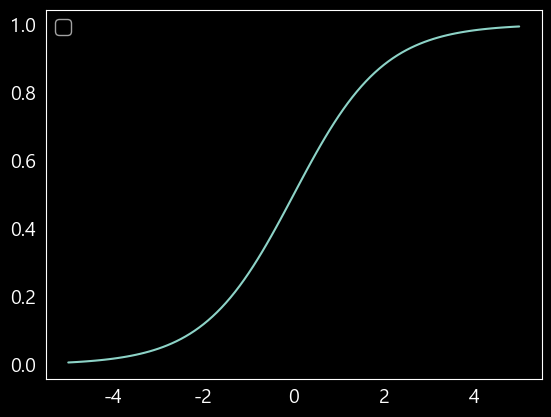

In [27]:
# 03. 로지스틱 회귀
# 단계 1: 입력변수를 1차 함수에 통과시켜 중간값 u를 계산한다.
# 단계 2: 2차 함수의 함수값 u를 '시그모이드 함수'에 통과시킨다.
# 이 함수의 치역은 0부터 1까지의 값이므로 함수값을 확률로 해석할 수 있다.
# 단계 3: 확률값 y의 값이 0.5보다 크면 1로 구분하고, 0.5보다 작으면

# 시그모이드 함수 정의
def sigmoid(x):
    return 1/ (1+np.exp(-x))

# x축 데이터 준비
x = np.linspace(-5, 5, 101)

# y축 데이터 준비
y = sigmoid(x)

# 그래프 작도
plt.plot(x, y)

# 범례 각도
plt.legend()

# 그리드 작도
plt.grid()

# 전체 그래프 출력
plt.show()

In [28]:
# 시그모이드 함수의 주요 특징
# 1) 함수값이 계속 증가한다.
# 2) 함수값이 0부터 1 사이의 값을 취한다.
# 3) 그래프의 모양이 x=0, y=0.5인 점을 중심으로 점대칭을 이룬다.
# 이러한 성질 덕분에 시그모이드 함수의 함수값은 확률처럼 사용할 수 있음
# 입력 값이 큰 음수라면 확률이 0에 가까워지고, 큰 양수라면 확률이 1에 가까워짐


{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 123, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


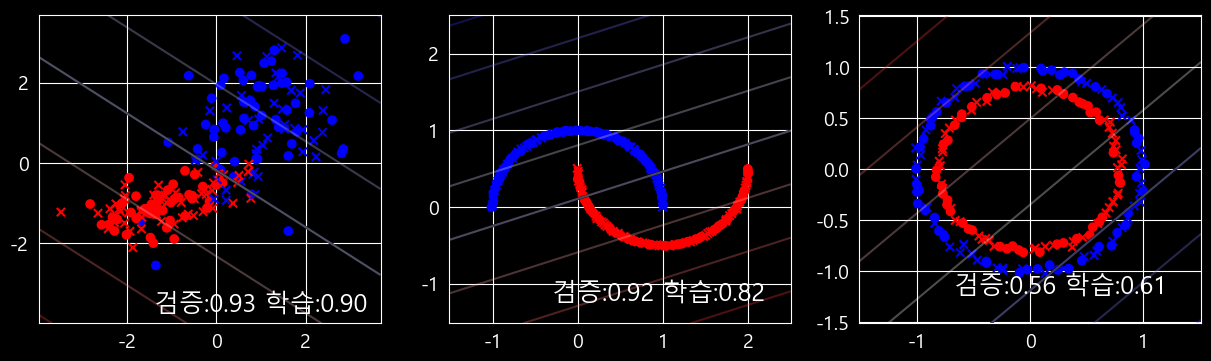

In [29]:
# 4/10(금) 시작
# 로지스틱 회귀 알고리즘을 이용한 분류 결과와 산점도

# 알고리즘 정의
from sklearn.linear_model import LogisticRegression

algorithm = LogisticRegression(random_state=random_seed)

# 알고리즘의 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

In [30]:
# 세 가지 예제 데이터 중 왼쪽의 선형 분리 가능 데이터는 검증 데이터와 학습 데이터 모두 거의 비슷한 정확도가 나옴
# 이와 달리 오른쪽 예제 데이터는 직선 형태의 결정 경계로 제대로 분류를 할 수 없기 때문에
# 분류 선응이 좋은 결정 경계를 발견하지 못했으며, 정확도는 55% ~ 60%에 머무름

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 123, 'shrinking': True, 'tol': 0.001, 'verbose': False}


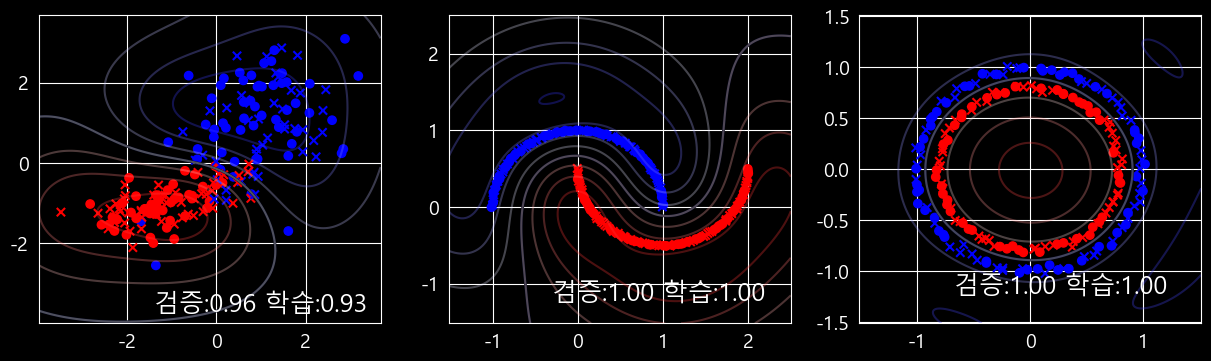

In [31]:
# 04 서포트 벡터 머신(커널)
# 컴퓨터 벡터: 1차원 배열의 데이터

# 직선으로만 결정 경계를 정하려고 하면, 두 번째, 세 번째 예제 데이터는 제대로 분류가 되지 않음
# 이러한 문제를 해결하기 위해 고안된 것이 서포트 벡터 머신의 '커널'

# 현재 목표는 직선으로 파란색 점과 검은 색 점을 분리하는 것
# 데이터를 제대로 분리할 수 없는 경우
# 2차원을 3차원으로 다시 배치할 수 있다면 평면으로 두 그룹을 나눌 수 있음
# 이것이 바로 커널의 밑바탕이 되는 아이디어

# 구체적으로 차원을 확장하는 방법은 가우시안 커널, 다항 커널, 시그모이드 커널 등 여러 알고리즘이 있음
# 가장 널리 쓰이는 것은 가우시안 커널로, 사이킷런 라이브러리를 사용한다면
# kernel='rbf' 옵션을 지정하면 됨

# SVM(커널)을 이용한 분류 결과 및 산점도

# 알고리즘 선택하기
from sklearn.svm import SVC

algorithm = SVC(kernel='rbf', random_state=random_seed)

# 알고리즘의 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

# 차원을 높임
# 예: 결핵, 백혈구 수치

In [32]:
# 로지스틱 회귀에 비하면 결과 차이가 남
# 로지스틱 회귀로 제대로 분리가 안됬던 두 번째와 세번째 예제 데이터의 경우
# 두 데이터 모두 데이터의 특성을 잘 살린 깔끔한 결정 경계를 찾아냄

# 결정 경계: 보라색

{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 123, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


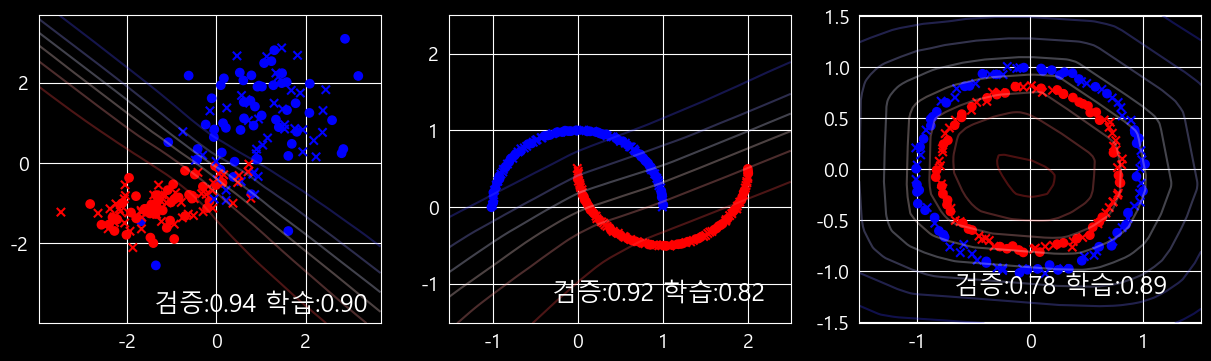

In [33]:
# 신경망 알고리즘
# 신경망은 말 그래도 뇌의 신경세포(뉴런)가 이루는 네트워크를 모방해 만든 알고리즘
# 원으로 표시된 것이 하나하나의 뇌세표에 해당하며, 세포 간의 결합을 통해 학습이 진행
# 중간층이 한 층뿐이지만, 이 중간층을 2층 이상으로 늘린 것이 딥러닝

# 층을 높이는 만큼 더욱 복잡한 모델을 만들 수 있으므로 우리가 사용하는 두 번째, 세 번째 예제 데이터 같은
# 선형 분리 불가능한 데이터에도 잘 맞는 결정 경계를 찾아낼 수 있음

# 알고리즘 선택하기
from sklearn.neural_network import MLPClassifier
algorithm = MLPClassifier(random_state=random_seed)

# 알고리즘에 설정된 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 123, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


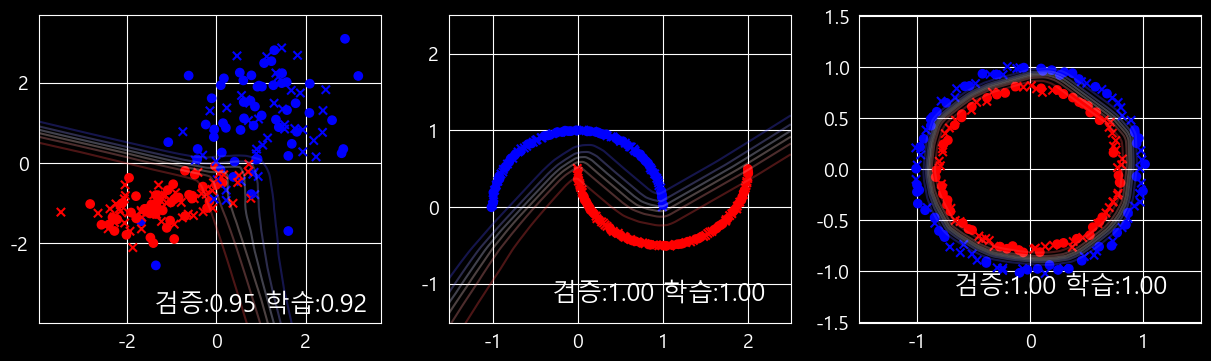

In [34]:
# 신경망 알고리즘을 이용한 분류 결과, 두 번째와 세 번째 예제 데이터를 보면, 확실히 결정 경계가 직선은 아니어도
# 데이터에 적합하다고 보기는 어려움
# 문제를 해결하기 위해 신경망의 파라미터 중 중간층 노드를 (100, 100)으로 변경
# 중간층의 수를 2개로 늘린다는 의미

# 2) 신경망 (중간층 2개 층)을 이용한 분류 결과와 산점도

# 알고리즘 선택하기
# 중간층 노드 수 = (100, 100)

from sklearn.neural_network import MLPClassifier

algorithm = MLPClassifier(hidden_layer_sizes=(100,100), random_state=random_seed)
# 알고리즘에 설정된 파라미터 출력
print(algorithm.get_params())
# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)


     sepal_length  sepal_width  petal_length  petal_width     species
50         7.0000       3.2000        4.7000       1.4000  versicolor
51         6.4000       3.2000        4.5000       1.5000  versicolor
52         6.9000       3.1000        4.9000       1.5000  versicolor
53         5.5000       2.3000        4.0000       1.3000  versicolor
54         6.5000       2.8000        4.6000       1.5000  versicolor
55         5.7000       2.8000        4.5000       1.3000  versicolor
56         6.3000       3.3000        4.7000       1.6000  versicolor
57         4.9000       2.4000        3.3000       1.0000  versicolor
58         6.6000       2.9000        4.6000       1.3000  versicolor
59         5.2000       2.7000        3.9000       1.4000  versicolor
60         5.0000       2.0000        3.5000       1.0000  versicolor
61         5.9000       3.0000        4.2000       1.5000  versicolor
62         6.0000       2.2000        4.0000       1.0000  versicolor
63         6.1000   

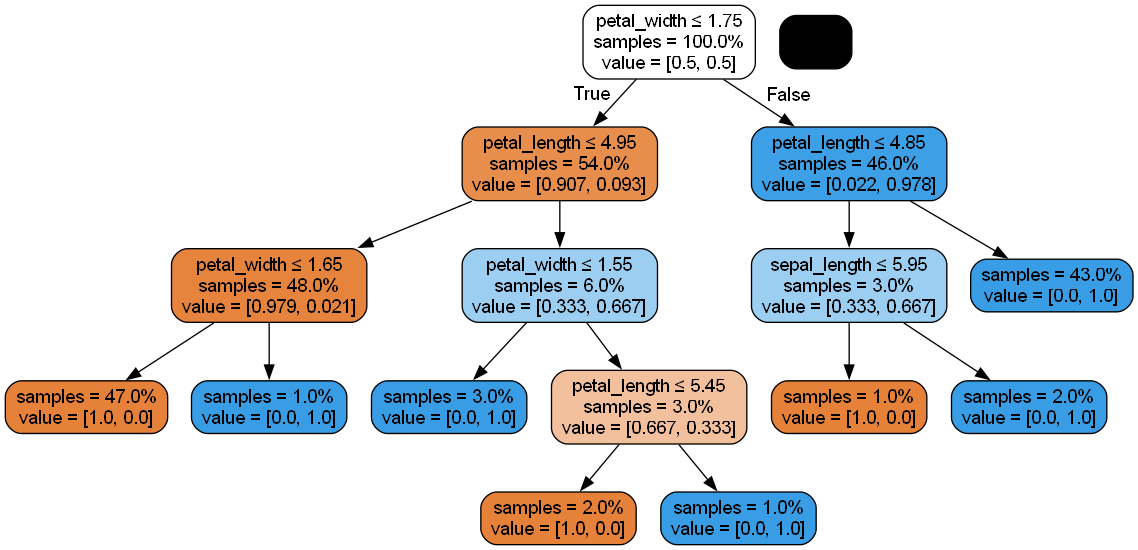

In [35]:
# 1) 아이리스 데이터 집합으로 결정 트리 그래프 그리기
# 추가 라이브러리 임포트
import seaborn as sns

df_iris = sns.load_dataset('iris')

# 데이터 범위를 2종으로 축소
df2 = df_iris[50:150]
print(df2)

# 데이터 분리
x = df2.drop('species', axis=1)
y = df2['species']

# InvocationException: GraphViz's executables not found : 이 오류 발생시에는
# https://graphviz.org/download/ 에서 환경에 맞는 비전을 설치하기
# 그래도 오류가 뜬다면 <설치경로>를 자신이 Graphviz를 설치한 경로로 수정한 후 진행
# 제미나이에게 해결하기


# **녹화본 설정 확인하기**



# 학습
from sklearn.tree import DecisionTreeClassifier

algorithm = DecisionTreeClassifier(random_state=random_seed)
algorithm.fit(x, y)

# 결정 트리를 그래프 구조로 출력
from sklearn import tree

with open('./output/iris-dtree.dot', mode = 'w') as f:
    tree.export_graphviz(algorithm, out_file=f,
                         feature_names=x.columns, filled=True, rounded=True,
                         special_characters=True, impurity=False, proportion=True)

import pydotplus
from IPython.display import Image

graph = pydotplus.graph_from_dot_file('./output/iris-dtree.dot')
graph.write_png('./output/iris-dtree.png')
Image(graph.create_png())


{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'}


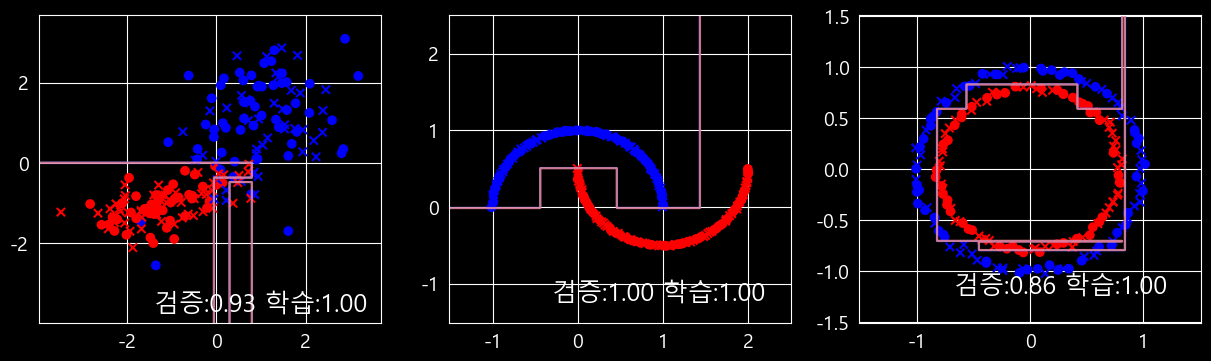

In [36]:
# iris 데이터 집합을 읽어 들인 뒤, 원래 세 가지 종의 데이터를 두 가지 종의 데이터로 추려낸 후
# 이 데이터로 결정 트리 모델을 학습한 뒤 트리의 분기 구조를 그래프 구조로 출력

# 맨 위에 있는 회색 사각형의 경우
# 사각형 속 세번째 줄의 value는 현재 분기에 내려온 데이터 중 두 그룹에 속하는 수를 나타냄
# [50, 50]이라고 나왔으므로 초기 상태에는 두 그룹의 데이터가 50개씩 있음을 알 수 있음

# 아이리스 데이터 집합에는 petal_length (꽃잎 길이), petal_width(꽃잎 폭),
# sepal_length (꽃받침 길이), sepal_width(꽃받침 폭)
# 네 개의 필드가 있음
# 그 중 먼저 petal_width(꽃잎 폭) 필드를 기준으로 필드 값이 1.75보다
# 작은지를 두고 첫 번째 분류를 수행하는 것이 맨 위 사각형의 의미

# 두 번째 사각형에는 value가 각각 [54.0], [46.0]로 되어 있어서 첫 번째 분류에서 이미 상당 부분 깔끔하게 분류가 되었음

# 그 아래의 처리도 같은 식으로 서브 그룹의 대상 필드와 역치를 설정한 후 역치를 기준으로 다 세세하게 분류를 해나감
# 이 과정이 결정 트리의 기본 처리 방식

# 만약 사람에게 '아이리스 데이터 집합에서 종을 분류할 규칙을 만들라'고 한다면 아마도 비슷한 규칙을 만들 것
# 이런 의미에서 결정 트리는 사람이 이해하기 쉬운 알고리즘


# 머신러닝에서는 판단 대성 필드의 기준이 되는 역치 값을 자동으로 설정하는 부분에서 머신러닝이 개입
# 이 판단 기준을 결정하는 방식에도 여러 가지가 있어서 사이킷런 라이브러리에서는 criterion이라는
# 파라미터에서 원하는 방식을 선택
# 기본 값은 지니 불순도 Gini impurity를 의미하는 gini

# 2) 결정 트리를 이용한 분류 결과와 산점도

# 알고리즘 선택하기
from sklearn.tree import DecisionTreeClassifier
algorithm = DecisionTreeClassifier(random_state=random_seed)

# 알고리즘에 설정된 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False}


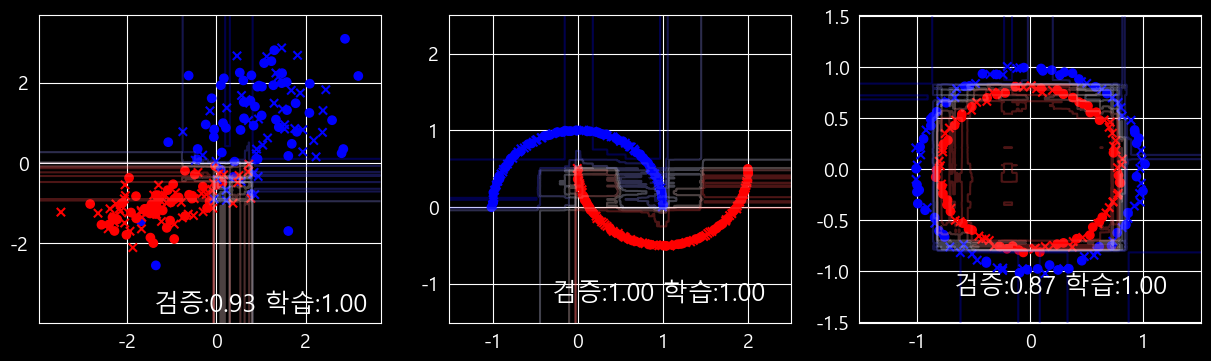

In [37]:
# 07. 랜덤 포레스트
# 결정 트리는 어떤 성질의 데이터도 유연하게 대응할 수 있는 것이 특징이지만, 과적합을 일으키기 쉬움
# 이러한 단점을 극복하기 위한 아이디어에서 제안된 것이 랜덤 포레스트
# 랜덤 포레스트의 바탕이 되는 아이디어는 '역분류가 weak classifier's라는 간단한 분류기를 여러 개 만들고
# 그 분류 결과의 다수결로 최종 판단을 내리자는 것

# 첫 단계는 원 학습 데이터에서 표본 데이터를 N세트(N은 약분류기의 수)를 만듬
# 표본을 추출할 때 데이터 중복을 허용하는 방법을 부트스트래핑 이라고 하는데, 이 방법을 사용
# 부트 스트래핑 : 실제 표본 데이터와 약간씩 다른 데이터를 만들어 여러 개의 새로운 데이터 집합을 구성하는 기법으로 통계학에서 많이 사용

# 다음 단계는 세트마다 분류에 사용할 변수를 무작위로 추려내 그 상태로 결정 트리를 N개 학습하는 것
# 당연하지만, 이렇게 학습한 분류기는 정확도가 떨어짐. 이렇게 만든 분류기를 약분류기라고 부르는 것은 이 때문

# 하지만 약 분류기의 결과를 모두 모아 다수결로 최종 결과를 결정하면 전체적으로 정확도가 높은 분류 결과가 나온다고 알려져있음
# 랜덤 포레스트 뜻이 무작위로 추려낸 여러 개의 결정 트리가 숲을 이룬다는 의미
# 언뜻 생각하면 쓸데없이 복잡하기만 한 것 같지만, 단순한 결정 트리와 비교하면 과적합을 잘 일으키지 않는 모델


# 랜덤 포레스트를 이용한 분류 결과와 산점도

from sklearn.ensemble import RandomForestClassifier
algorithm = RandomForestClassifier(random_state=random_seed)

# 알고리즘에 설정된 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

In [38]:
# 회색과 파란색이 이루는 경계를 중심으로 각 그림을 살펴보면 경계선이 자연스러워 진 것을 알 수 있음

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 123, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


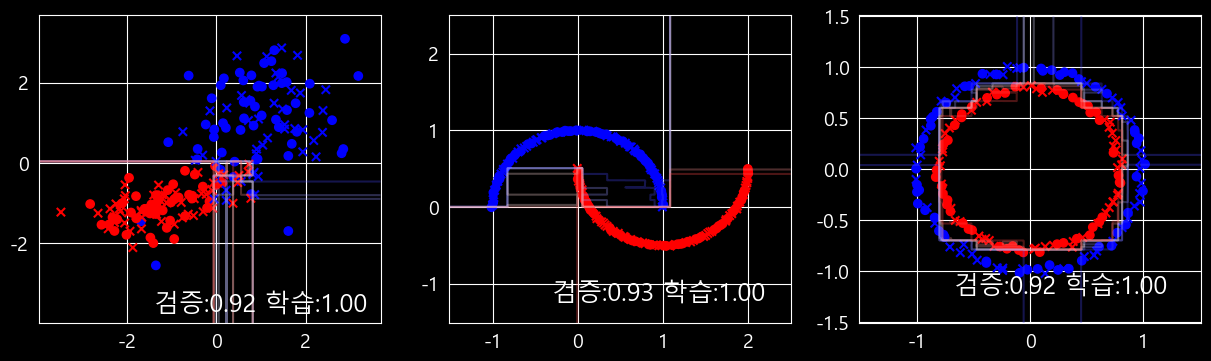

In [39]:
# 08. XGBoost
# XGBoost는 eXtreme Gradient Boosting의 약자로, 2014년 제안된 알고리즘
# 최근 캐글(Kaggle) 등 머신러닝 모델 콘테스트에서 널리 사용
# 알고리즘의 구체적인 내용은 복잡

# XGGoost를 아주 간단히 설명하면, 분류의 여러 개의 결정 트리를 사용하는 기법인 '앙상블'과 '배깅', '부스팅'을 결합한 알고리즘
# 배깅 bagging은 서로 무관한 약분류기를 병렬로 만들어 그 분류 결과를 다수결로 최종 결과를 결정하는 기법
# 랜덤 포레스트가 바로 배깅이 적용된 결정 트리

# 부스팅 boosting 역시 여러 개의 분류기를 사용한다는 점은 배깅과 같지만,
# 배깅이 '여러 개의 분류기를 서로 무관하게 학습' 시키는 데 반해,
# 부스팅은 '바로 전 분류기의 결과를 기초로 다음 분류기를 학습'한다는 점이 차이

# 첫 번째 분류기는 일반적인 방법으로 학습. 이 분류기의 예측 결과는 정답 데이터와 차이가 있을 것이고 이 차이를 계산
# 그 다음 분류기는 앞에서 구한 오차1을 예측하게 학습.
# 이런 방식으로 분류기를 여러 개 만든 다음, 그 결과를 겹쳐 가며 더 하는 방법으로 최종 분류기를 만듬

# XGBoost의 실제 학습 원리는 이보다 훨씬 복잡하지만, 학습이 진행되는 개념적인 형태는 위와 같음

# XGBoost를 이용한 분류 결과 산점도

# 알고리즘 선택하기
import xgboost
algorithm = xgboost.XGBClassifier(random_state=random_seed)


# 알고리즘에 설정된 파라미터 출력
print(algorithm.get_params())

# 결과 표시 함수를 호출
plot_boundaries(algorithm, DataList)

In [40]:
# XGBoost는 파라미터가 여러 개 있어서 파라미터의 값을 적절히 설정하지 못하면 정확도가 나오지 않음
# 이번 결과에서 오른쪽 데이터에 대한 정확도가 그리 높지 못한 것도 이 때문

In [41]:
# 09. 알고리즘을 선택하는 방법
# 무슨 알고리즘을 써야 할까?에 대한 물음에 간단히 답하기는 어려움

# 1) 모델의 판단 근거를 알고 싶다.
# 모델의 판단 근거를 아는 것도 알고리즘을 선택하는 중요한 기준 중 하나
# 알고리즘 중 로지스틱 회귀와 결정 트리는 모델의 구조가 단순한 만큼 '모델의 예측 결과가 도출되는 과정'을
# 사람이 쉽게 이해할 수 있음
# 머신러닝을 활용할 업무가 이러한 점을 중시하는 업무라면 로지스틱 회귀와 결정 트리가 유리

# 2) 정확도가 좋은 모델
# 모델이 판단하는 이유는 달라도 되지만, 가능한 한 정확한 예측 결과가 필요한 경우
# 서포트 벡터 머신(커널), 신경망, 랜덤 포레스트, XGBoost 같은 알고리즘을 주로 선택
# 최대한 정확도가 높은 모델이 필요한 상황에서는 같은 데이터로 여러 개의 모델을 학습해
# 정확도를 비교한 뒤 가장 뛰어난 것을 선택하는 방법이 표준
# 구체적인 방법으로는 교차 검증, 그리드 서치 등의 기법이 있음

# 3) 학습에 걸리는 시간
# 예제 데이터는 데이터 건수나 필드 수가 적기 때문에 학습 시간이 그리 오래 걸리지 않았음
# 그러나 실제 프로젝트에서 다루는 학습 데이터는 경우에 따라 많게는 수천만건, 필드 수도 수백에서 수천에 이르는 경우가 있음
# 이런 경우에는 학습에 걸리는 시간도 알고리즘을 선택하는 기준이 될 수 있음
# 알고리즘이 간단한 로지스틱 회귀와 결정 트리가 그만큼 학습 시간되 짧기 때문에 유리


